# (IIP314W-2) [2026-T2] OPTIMIZACIÓN APLICADA A NEGOCIOS
## Ayudantía 1: Puntos críticos y gradiente descendente

---

**Profesor:** Rodrigo Trigo Vilches

**Ayudante:** Vicente Ramírez

**Fecha:** 03 de junio de 2026

**Universidad del Desarrollo**

---

## Objetivos de la ayudantía

- Encontrar y clasificar **puntos críticos** en una y dos variables.
- Aplicar el **criterio de la segunda derivada** (1D) y el **Hessiano** (2D) para clasificar puntos críticos como mínimo, máximo o **punto silla**.
- Implementar el **descenso de gradiente** a mano y en código.
- Comparar el paso **normalizado** vs **no normalizado** y entender por qué afectan la convergencia.

## Repaso breve de conceptos

**Punto crítico (1D):** valor $x$ donde $f'(x)=0$. **Multivariable:** punto donde $\nabla f(x)=\mathbf{0}$.

**Criterio de la segunda derivada (1D):**
- Si $f''(x^*) < 0 \Rightarrow$ máximo local.
- Si $f''(x^*) > 0 \Rightarrow$ mínimo local.
- Si $f''(x^*) = 0 \Rightarrow$ no concluyente (posible inflexión).

**Criterio de segundo orden (2D, Hessiano):** con $D = \det H = f_{xx}f_{yy} - (f_{xy})^2$: si $D>0$ y $f_{xx}>0\Rightarrow$ mínimo; si $D>0$ y $f_{xx}<0\Rightarrow$ máximo; si $D<0\Rightarrow$ **punto silla**; si $D=0\Rightarrow$ no concluyente.

**Equivalencia max $\leftrightarrow$ min:** $\max f(x) = -\min(-f(x))$. La literatura trabaja siempre en minimización.

**Condición de primer orden multivariable:** el óptimo interior cumple $\nabla f = \mathbf{0}$.

**Descenso de gradiente — regla de actualización:**
$$x_{k+1} = x_k - \alpha\,\nabla f(x_k) \quad\text{(no normalizado)}$$
$$x_{k+1} = x_k - \alpha\,\frac{\nabla f(x_k)}{\lVert \nabla f(x_k)\rVert} \quad\text{(normalizado)}$$

**Criterio de parada:** $\lVert \nabla f(x_k)\rVert < \varepsilon$ (tolerancia) o alcanzar el máximo de iteraciones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Ejercicio 1 — Fijación de precio (1 variable, puntos críticos)

Una empresa modela su utilidad (en millones de pesos) en función del precio unitario $p$ de su producto como:

$$U(p) = -3p^2 + 60p - 150$$

**Tareas:**
1. Encontrar el precio óptimo $p^*$ resolviendo $U'(p)=0$.
2. Clasificar el punto crítico con el criterio de la segunda derivada.
3. Calcular la utilidad máxima $U(p^*)$.
4. Graficar $U(p)$ en un rango razonable marcando el óptimo.

### Solución analítica

_Desarrolle aquí $U'(p)=0$, el criterio de la segunda derivada y $U(p^*)$:_

- $U'(p) = $ 
- $p^* = $ 
- $U''(p) = $  $\Rightarrow$ clasificación: 
- $U(p^*) = $ 
- Interpretación: 

In [4]:
# Verificacion simbolica con sympy
# Defina el simbolo p, la funcion U, calcule dU y d2U, resuelva dU=0 y evalue U(p*).
#### CÓDIGO AQUÍ ####
p = sp.symbols('p', real = True)
u = -3*p**2 + 60*p -150

du = sp.diff(u, p)
ddu = sp.diff(u, p, 2)

u_op = sp.solve(du, p)[0]
print(u_op)

10


In [ ]:
# Grafico de la utilidad
# Defina U_obj como lambda, genere p_vals con np.linspace y marque el optimo.
#### CÓDIGO AQUÍ ####


## Ejercicio 2 — Costo de producción (1 variable, gradiente descendente)

El costo de producción (en miles de pesos) de una planta en función de la cantidad producida $q$ (en miles de unidades) es:

$$C(q) = q^2 - 8q + 20$$

**Tareas:**
1. Encontrar analíticamente el mínimo resolviendo $C'(q)=0$.
2. Realizar **3 iteraciones de descenso de gradiente a mano** y mostrar los pasos en una tabla.
3. Implementar el descenso de gradiente en código y confirmar la convergencia a $q^*$.
4. Graficar la convergencia.

### (a) Solución analítica

_Desarrolle $C'(q)=0$ y clasifique:_

- $C'(q) = $  $\Rightarrow$ $q^* = $ 
- $C''(q) = $  $\Rightarrow$ clasificación: 
- $C(q^*) = $ 

### (b) Descenso de gradiente a mano

Use el **paso no normalizado** $q \leftarrow q - \alpha\,C'(q)$ con $q_0 = 0$ y $\alpha = 0.25$, donde $C'(q) = 2q - 8$. Complete la tabla:

| Iteración $k$ | $q_k$ | $C'(q_k) = 2q_k - 8$ | $q_{k+1} = q_k - 0.25\,C'(q_k)$ |
|:---:|:---:|:---:|:---:|
| 0 |  |  |  |
| 1 |  |  |  |
| 2 |  |  |  |
| 3 |  |  |  |

3.9999990463256836


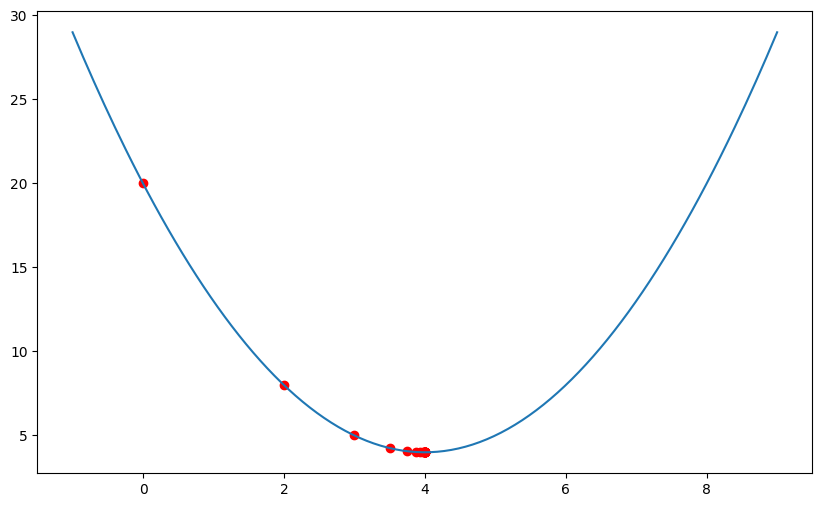

In [9]:
# (c) Implementacion del descenso de gradiente en 1D
C = lambda q: q**2 - 8*q + 20
dC = lambda q: 2*q - 8

def descenso_gradiente_1d(df, q0, alpha=0.25, tol=1e-6, max_iters=100):
    # in: derivada, punto inicial, tasa de aprendizaje, tolerancia, max iteraciones
    # out: minimo aproximado e historial de q
    q = q0
    historial = [q]

    for _ in range(max_iters):
        res = q - alpha*df(q)
        historial.append(res)
        if abs(res - q) <= tol:
            q = res
            break
        q = res

    #### CÓDIGO AQUÍ ####
    # Itere: calcule el gradiente, aplique el criterio de parada,
    # actualice q (paso NO normalizado) y guarde en historial.
    return q, np.array(historial)
opt, hist = descenso_gradiente_1d(dC, 0)
# q_aprox, historial = descenso_gradiente_1d(dC, q0=0, alpha=0.25)
# print(q_aprox, C(q_aprox), len(historial) - 1)
print(opt)

valores = np.linspace(-1, 9, 200)

fig = plt.figure(figsize=(10,6))

plt.plot(valores, C(valores), label='C')
plt.scatter(hist, C(hist), color = "red", label="gradiente")
plt.show()

In [ ]:
# (d) Grafico de la convergencia
# Grafique la trayectoria sobre C(q) y el valor de q por iteracion.
#### CÓDIGO AQUÍ ####


## Ejercicio 3 — Ajuste de un modelo con dos hiperparámetros (puntos críticos, clasificación y descenso de gradiente)

El equipo de *analytics* de una empresa ajusta un modelo de demanda que depende de dos hiperparámetros $x$ e $y$. El **error de validación** (la función de pérdida que se busca minimizar) resultó ser:

$$L(x,y) = x^4 - 2x^2 + y^2 - 2y + 1$$

**Tareas:**
1. Encontrar **todos** los puntos críticos resolviendo $\nabla L = \mathbf{0}$.
2. Clasificar cada punto crítico (máximo, mínimo o **punto silla**) con el **Hessiano** (criterio de segundo orden en dos variables).
3. Determinar el mínimo global e indicar si es único.
4. Implementar el descenso de gradiente en 2D en **dos variantes** (paso **normalizado** y **no normalizado**) y comparar la convergencia.
5. Confirmar el óptimo con `scipy.optimize.minimize`.
6. Discutir qué ocurre si el descenso parte justo sobre el punto silla.

### (a) Puntos críticos: $\nabla L = \mathbf{0}$

_Escriba el gradiente, iguale cada componente a cero y encuentre **todos** los puntos críticos:_

- $\nabla L(x,y) = $
- $\dfrac{\partial L}{\partial x} = 0 \Rightarrow x = $
- $\dfrac{\partial L}{\partial y} = 0 \Rightarrow y = $
- Puntos críticos: 

### (b) Clasificación con el Hessiano

_Escriba el Hessiano y aplique el criterio de segundo orden ($D = \det H = L_{xx}L_{yy} - (L_{xy})^2$):_

$$H(x,y) = \begin{pmatrix} L_{xx} & L_{xy} \\ L_{yx} & L_{yy} \end{pmatrix} = \begin{pmatrix} \phantom{xxxx} & \phantom{xxxx} \\ \phantom{xxxx} & \phantom{xxxx} \end{pmatrix}$$

Recuerde: $D>0$ y $L_{xx}>0 \Rightarrow$ mínimo; $D>0$ y $L_{xx}<0 \Rightarrow$ máximo; $D<0 \Rightarrow$ punto silla.

| Punto | $L_{xx}$ | $D$ | Clasificación | $L$ |
|:---:|:---:|:---:|:---:|:---:|
|  |  |  |  |  |
|  |  |  |  |  |
|  |  |  |  |  |

### (c) Mínimo global

_¿Cuál es el valor mínimo global? ¿En qué punto(s) se alcanza? ¿Es único? (Pista: complete cuadrados.)_

_Respuesta:_ 

In [ ]:
# Verificacion simbolica: puntos criticos, Hessiano y clasificacion
# Defina los simbolos x, y; la funcion L_sym; resuelva grad=0 con sp.solve;
# obtenga el Hessiano con sp.hessian y clasifique cada punto con D y Lxx.
#### CÓDIGO AQUÍ ####


In [ ]:
# (d) Descenso de gradiente en 2D: variantes normalizada y no normalizada
L = lambda x, y: x**4 - 2*x**2 + y**2 - 2*y + 1
gradiente = lambda x, y: np.array([4*x**3 - 4*x, 2*y - 2])

def descenso_gradiente_2d(grad_fn, X0, alpha, normalizado=False,
                          tol=1e-3, max_iters=1000):
    # in: gradiente, punto inicial, tasa, flag normalizado, tolerancia, max iters
    # out: punto final, historial, numero de iteraciones
    X = np.array(X0, dtype=float)
    historial = [X.copy()]
    iteracion = 0
    #### CÓDIGO AQUÍ ####
    # Itere: calcule el gradiente g, aplique criterio de parada ||g|| < tol,
    # construya el paso (normalizado o no segun el flag), actualice X y guarde.
    return X, np.array(historial), iteracion

# X0 = (0.5, 0.5); alpha = 0.1
# X_norm, hist_norm, it_norm = descenso_gradiente_2d(gradiente, X0, alpha, normalizado=True)
# X_nonorm, hist_nonorm, it_nonorm = descenso_gradiente_2d(gradiente, X0, alpha, normalizado=False)


In [ ]:
# Distancia al minimo global mas cercano (1, 1)
# Calcule la distancia euclidiana de cada variante a (1, 1).
#### CÓDIGO AQUÍ ####


In [ ]:
# (e) Confirmacion con scipy.optimize.minimize (Nelder-Mead, como en la Clase 3)
# Importe minimize, defina L_obj(v) y lance la busqueda desde (0.5, 0.5) y (-0.5, 0.5).
# Observe que el resultado depende de la cuenca de partida.
#### CÓDIGO AQUÍ ####


### (d) Tabla comparativa del descenso de gradiente

Complete con los resultados de su código ($\alpha = 0.1$, $X_0=(0.5,\,0.5)$, $\varepsilon = 10^{-3}$, máx. 1000 iteraciones):

| Variante | Punto inicial | Iteraciones | Mínimo hallado $(x,y)$ | $L$ hallado | Óptimo real | Distancia al óptimo |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| Normalizado |  |  |  |  | $(1,1)$ |  |
| No normalizado |  |  |  |  | $(1,1)$ |  |

In [ ]:
# (f) Curvas de nivel con las tres soluciones y ambas trayectorias
# Use np.meshgrid + plt.contour sobre L; superponga hist_norm y hist_nonorm;
# marque los minimos (±1, 1) y el punto silla (0, 1).
#### CÓDIGO AQUÍ ####


In [ ]:
# (g) Que pasa si partimos justo sobre la cresta x = 0 (hacia el punto silla)
# Ejecute el descenso (no normalizado) desde (0.0, 0.5) e interprete el resultado.
#### CÓDIGO AQUÍ ####


### (e) Discusión

Responda con sus palabras:

- ¿Por qué un punto con $\nabla L = \mathbf{0}$ puede **no** ser un óptimo? ¿Qué rol juega el Hessiano?
- ¿Por qué el paso **no normalizado** converge al mínimo y el **normalizado** se queda oscilando?
- ¿Qué le pasó al descenso al partir sobre la cresta $x=0$? ¿Qué precauciones tomaría en la práctica?

_Respuesta:_ 